In [1]:
import os
import torch
from torch.nn.functional import smooth_l1_loss
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
import json
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, random_split
from torchvision.ops import box_iou
from tqdm import tqdm
import matplotlib.pyplot as plt
import torchinfo

In [2]:
ROOT_PATH = ""
MODEL_NAME = "garbage_classification"
TRAIN_BATCH_SIZE = 6
VAL_BATCH_SIZE = 2
TEST_BATCH_SIZE = 1

In [3]:
class GarbageCocoDataset(Dataset):
    def __init__(self, root, annotation_file, transforms=None):
        self.root = root
        self.transforms = transforms
        with open(annotation_file) as f:
            self.coco = json.load(f)
        self.image_id_map = {img['id']: img for img in self.coco['images']}
        self.annotations = {}
        for ann in self.coco['annotations']:
            img_id = ann['image_id']
            self.annotations.setdefault(img_id, []).append(ann)
        self.ids = list(self.image_id_map.keys())
        self.class_map = {cat['id']: cat['name'] for cat in self.coco['categories']}
        self.label_map = {cat['id']: idx + 1 for idx, cat in enumerate(self.coco['categories'])}  # 0 is background

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.image_id_map[img_id]
        img_path = os.path.join(self.root, img_info['file_name'])
        img = Image.open(img_path).convert("RGB")

        boxes, labels = [], []
        for ann in self.annotations.get(img_id, []):
            bbox = ann['bbox']  # [x, y, width, height]
            x, y, w, h = bbox
            if x >= 0 and y >= 0 and w > 0 and h > 0:
                boxes.append([x, y, x + w, y + h])
                labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id])
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.ids)


In [4]:
def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn_v2(
        weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1,
        trainable_backbone_layers=0
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


In [5]:
def save_model(model, epoch):
    file_name = MODEL_NAME + f"_{epoch}.pth"
    model_path = ROOT_PATH + file_name
    torch.save(model.state_dict(), model_path)
    print(f"Model state_dict saved to {model_path}")

In [6]:
def plot_losses(train_loss, val_loss):
    epochs = len(train_loss)
    plt.figure(figsize=(10, 6)) # Set the figure size for better readability

    # Plot training loss
    plt.plot(range(1, epochs + 1), train_loss, label='Training Loss', color='blue', linestyle='-')

    # Plot validation loss
    plt.plot(range(1, epochs + 1), val_loss, label='Validation Loss', color='red', linestyle='--')

    # Add title and labels
    plt.title('Training and Validation Loss Over Epochs', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)

    # Add a legend to distinguish the lines
    plt.legend(fontsize=10)

    # Add a grid for better readability
    plt.grid(True, linestyle=':', alpha=0.7)

    # Customize tick marks
    plt.xticks(np.arange(0, epochs + 1, max(1, epochs // 10))) # Show ticks every 10 epochs or more frequently for fewer epochs
    plt.yticks(fontsize=10)
    plt.show()


In [7]:
def validation_loss(boxes, targets):
    return sum(smooth_l1_loss(b, t) for b, t in zip(boxes, targets))


In [8]:

def collate_fn(batch):
    return tuple(zip(*batch))

def get_transform():
    return T.Compose([T.Grayscale(), T.ToTensor()])

def evaluate(model, data_loader, device):
    model.eval()
    iou_scores = []
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = list(img.to(device) for img in images)
            outputs = model(images)
            for output, target in zip(outputs, targets):
                if len(output["boxes"]) == 0 or len(target["boxes"]) == 0:
                    continue
                ious = box_iou(output["boxes"].cpu(), target["boxes"].cpu())
                iou_scores.append(ious.max().item())

    avg_iou = np.mean(iou_scores) if iou_scores else 0
    print(f"Avg IoU: {avg_iou:.4f}")
    return avg_iou

def train_model(model, train_loader, val_loader, device, epochs=10, lr=0.005):
    model.to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    loss_history = []
    val_loss_history = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_loss += losses.item()

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            ############################
            # VALIDATION
            ############################
            total_val_loss = 0.0
            with torch.no_grad():
              for images, targets in val_loader:
                  images = list(img.to(device) for img in images)
                  targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                  loss_dict = model(images, targets)
                  losses = sum(loss for loss in loss_dict.values())
                  total_val_loss += losses.item()

        loss_history.append(epoch_loss)
        val_loss_history.append(total_val_loss)
        lr_scheduler.step()
        print(f"Epoch {epoch+1} loss: {epoch_loss:.4f} validation loss: {total_val_loss}")
        evaluate(model, val_loader, device)
    plot_losses(loss_history, val_loss_history)


In [9]:
# Load train / valid / test datasets from separate folders

train_dir = ROOT_PATH + "data/train"
valid_dir = ROOT_PATH + "data/valid"
test_dir  = ROOT_PATH + "data/test"

train_ann = os.path.join(train_dir, "_annotations.coco.json")
valid_ann = os.path.join(valid_dir, "_annotations.coco.json")
test_ann  = os.path.join(test_dir,  "_annotations.coco.json")

transform = get_transform()

train_ds = GarbageCocoDataset(train_dir, train_ann, transforms=transform)
val_ds   = GarbageCocoDataset(valid_dir, valid_ann, transforms=transform)
test_ds  = GarbageCocoDataset(test_dir,  test_ann, transforms=transform)

train_loader = DataLoader(train_ds, batch_size=6, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)


In [10]:
print("training set size:", len(train_ds))
print("validation set size:", len(val_ds))
print("test set size:", len(test_ds))

training set size: 7324
validation set size: 2098
test set size: 1042


In [11]:
train_ds[0][1]['labels'].item()

3

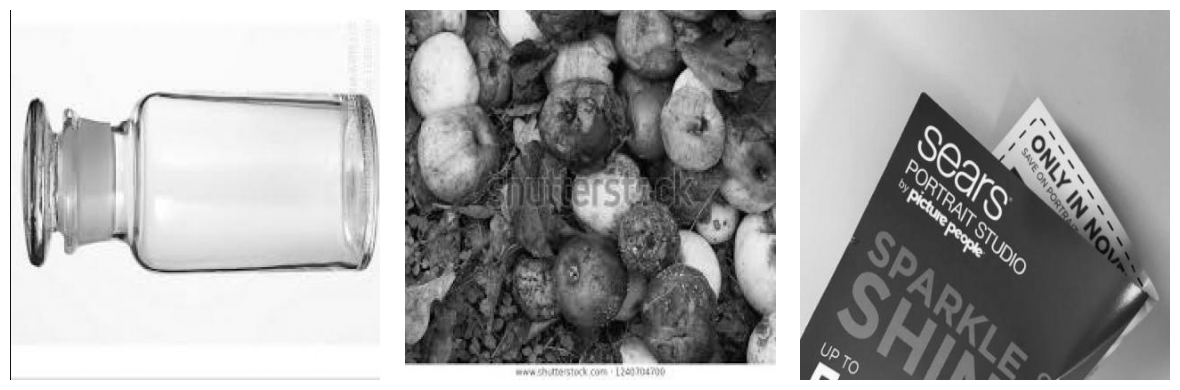

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(train_ds[0][0].permute(1, 2, 0), cmap='gray')
axes[1].imshow(val_ds[0][0].permute(1, 2, 0), cmap='gray')
axes[2].imshow(test_ds[0][0].permute(1, 2, 0), cmap='gray')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes=7)

torchinfo.summary(model, input_size=(TRAIN_BATCH_SIZE, 1, 416, 416))
#train_model(model, train_loader, val_loader, device, epochs=5)


Layer (type:depth-idx)                             Output Shape              Param #
FasterRCNN                                         [100, 4]                  --
├─GeneralizedRCNNTransform: 1-1                    [6, 3, 800, 800]          --
├─BackboneWithFPN: 1-2                             [6, 256, 13, 13]          --
│    └─IntermediateLayerGetter: 2-1                [6, 2048, 25, 25]         --
│    │    └─Conv2d: 3-1                            [6, 64, 400, 400]         (9,408)
│    │    └─BatchNorm2d: 3-2                       [6, 64, 400, 400]         (128)
│    │    └─ReLU: 3-3                              [6, 64, 400, 400]         --
│    │    └─MaxPool2d: 3-4                         [6, 64, 200, 200]         --
│    │    └─Sequential: 3-5                        [6, 256, 200, 200]        (215,808)
│    │    └─Sequential: 3-6                        [6, 512, 100, 100]        (1,219,584)
│    │    └─Sequential: 3-7                        [6, 1024, 50, 50]         (7,098,368)
│ 

In [15]:
model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [14]:
#evaluate(model, test_loader, device)